## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef
)

In [ ]:
from pathlib import Path

BASE_DIR  = Path.cwd().parent   # notebooks run from notebooks/ subfolder
RAW       = BASE_DIR / "data" / "raw"
PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS   = BASE_DIR / "outputs"
MODELS    = BASE_DIR / "models"

## Load Dataset

In [ ]:
# Load features and target
X = pd.read_csv(PROCESSED / "features_extracted.csv")
y = pd.read_csv(PROCESSED / "target_variable.csv").squeeze()  # Assuming target_variable.csv has a single column

# Load original dataset (audio features live here)
df = pd.read_csv(PROCESSED / "lyrics_preprocessed.csv")

# --- Clean indices ---
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
df = df.reset_index(drop=True)

print("Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("df:", df.shape)

In [409]:
df.columns

Index(['spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
       'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'entry_date', 'exit_date',
       'days_in_top50', 'lyrics', 'language', 'lyrics_length', 'lyrics_clean',
       'word_count', 'lyrics_preproc_v2', 'tokens'],
      dtype='str')

In [410]:
# Sanity checks

# Same number of rows
assert X.shape[0] == y.shape[0], "X and y have different number of rows!"

# Index alignment
assert X.index.equals(y.index), "X and y indices are not aligned!"

print("Basic alignment between X and y is correct.")

Basic alignment between X and y is correct.


## Feature Groups

In [411]:
print(X.columns[:20])
print(len(X.columns))

Index(['ttr', 'avg_word_length', 'repetition_ratio', 'max_word_freq',
       'sentiment_polarity', 'abandoned', 'account', 'ace', 'across', 'act',
       'act like', 'actin', 'actin like', 'action', 'actually', 'add',
       'addict', 'addicted', 'addiction', 'address'],
      dtype='str')
2643


In [412]:
linguistic_cols = [
    "ttr",
    "avg_word_length",
    "repetition_ratio",
    "max_word_freq",
    "sentiment_polarity"
]

# Separate TF-IDF features
tfidf_cols = [col for col in X.columns if col not in linguistic_cols]

X_ling = X[linguistic_cols]
X_tfidf = X[tfidf_cols]

# Combined lyrics model
X_combined = X.copy()

## Train/Test Split

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# ── Audio features — aligned to the same rows as X (features_extracted) ──
audio_cols = [
    "danceability", "energy", "valence", "tempo",
    "loudness", "speechiness", "acousticness", "instrumentalness"
]
X_audio = df.loc[X.index, audio_cols].reset_index(drop=True)

# NaN check before splitting
print("NaN check  — TF-IDF:", X_tfidf.isna().sum().sum(),
      "| Audio:", X_audio.isna().sum().sum(),
      "| y:", y.isna().sum())

# ── Single stratified split — same idx_train / idx_test for every model ──
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=42
)
y_train = y.iloc[idx_train].reset_index(drop=True)
y_test  = y.iloc[idx_test].reset_index(drop=True)

def split_X(Xdf):
    """Split a DataFrame/Series using the global idx_train / idx_test."""
    return (Xdf.iloc[idx_train].reset_index(drop=True),
            Xdf.iloc[idx_test].reset_index(drop=True))

X_ling_train,  X_ling_test  = split_X(X_ling)
X_tfidf_train, X_tfidf_test = split_X(X_tfidf)
X_audio_train, X_audio_test = split_X(X_audio)

# Preprocessed text aligned to X for DTM / LDA fitting
text_series = df.loc[X.index, "lyrics_preproc_v2"].reset_index(drop=True)
text_train  = text_series.iloc[idx_train].reset_index(drop=True)
text_test   = text_series.iloc[idx_test].reset_index(drop=True)

print(f"Train: {len(y_train)} | Test: {len(y_test)}")

In [ ]:
# TF-IDF reduction: SelectKBest top 1000 features — fit on train only
k = 1000
selector = SelectKBest(score_func=f_classif, k=k)

X_tfidf_train_selected = selector.fit_transform(X_tfidf_train, y_train)
X_tfidf_test_selected  = selector.transform(X_tfidf_test)

selected_features = X_tfidf_train.columns[selector.get_support()]

X_tfidf_train_selected = pd.DataFrame(
    X_tfidf_train_selected, columns=selected_features
)
X_tfidf_test_selected = pd.DataFrame(
    X_tfidf_test_selected, columns=selected_features
)
print("Selected TF-IDF shape:", X_tfidf_train_selected.shape)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Raw word counts (Document-Term Matrix) — CountVectorizer fit on train only
cv = CountVectorizer(max_features=1000)

X_dtm_train = pd.DataFrame(
    cv.fit_transform(text_train).toarray(),
    columns=cv.get_feature_names_out()
)
X_dtm_test = pd.DataFrame(
    cv.transform(text_test).toarray(),
    columns=cv.get_feature_names_out()
)
print("DTM shape — train:", X_dtm_train.shape, "| test:", X_dtm_test.shape)

## LDA Feature Extraction

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Fit LDA on training DTM only (k=5 topics — matches LDA notebook)
N_TOPICS = 5

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=20
)

X_lda_train = pd.DataFrame(
    lda.fit_transform(X_dtm_train),
    columns=[f"lda_topic_{i}" for i in range(N_TOPICS)]
)
X_lda_test = pd.DataFrame(
    lda.transform(X_dtm_test),
    columns=[f"lda_topic_{i}" for i in range(N_TOPICS)]
)
print("LDA topics shape — train:", X_lda_train.shape, "| test:", X_lda_test.shape)

## Evaluation Helper

In [ ]:
all_results = []   # populated as each model runs

THRESHOLD = 0.3

def evaluate_model(X_train, X_test, y_train, y_test, name, features_used=""):
    """
    Train a LogisticRegression, evaluate with 7 metrics, and display
    Confusion Matrix + ROC curve + PR curve.
    Returns a results dict for the final comparison table.
    """
    # Scale inside function (fit on train, apply to test)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    clf = LogisticRegression(
        solver="liblinear", max_iter=5000, C=10, class_weight="balanced"
    )
    clf.fit(X_tr, y_train)

    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)

    # ── Metrics ──────────────────────────────────────────────────
    acc      = accuracy_score(y_test, y_pred)
    kappa    = cohen_kappa_score(y_test, y_pred)
    mcc      = matthews_corrcoef(y_test, y_pred)
    auc      = roc_auc_score(y_test, y_prob)
    ap       = average_precision_score(y_test, y_prob)
    rep_dict = classification_report(
        y_test, y_pred, target_names=["Flop", "Hit"], output_dict=True
    )
    macro_f1 = rep_dict["macro avg"]["f1-score"]

    # ── Console output ────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  {name}")
    print(f"{'='*62}")
    print(f"  Accuracy : {acc:.4f}   Kappa : {kappa:.4f}   MCC : {mcc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}   Avg Precision (PR) : {ap:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Flop", "Hit"]))

    # ── Plots: Confusion Matrix | ROC Curve | PR Curve ────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontweight="bold", fontsize=13)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Flop", "Hit"], yticklabels=["Flop", "Hit"])
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color="#2D6A9F", lw=2, label=f"AUC = {auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    # Precision-Recall Curve
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    axes[2].plot(rec_arr, prec_arr, color="#3AA5A0", lw=2, label=f"AP = {ap:.3f}")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].legend(loc="upper right")

    plt.tight_layout()
    safe_name = name[:40].replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
    plt.savefig(OUTPUTS / f"eval_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "Model":               name,
        "Features Used":       features_used,
        "Accuracy":            round(acc, 4),
        "Macro F1":            round(macro_f1, 4),
        "AUC-ROC":             round(auc, 4),
        "Avg Precision (PR)":  round(ap, 4),
        "Kappa":               round(kappa, 4),
        "MCC":                 round(mcc, 4),
        "_clf":                clf,
        "_scaler":             scaler,
    }

## Model 1 — Baseline: Audio Features Only

Baseline established by the literature: audio-only models are the standard starting point for chart persistence prediction.

In [ ]:
res1 = evaluate_model(
    X_audio_train, X_audio_test,
    y_train, y_test,
    name="Model 1 — Audio Features Only",
    features_used="danceability, energy, valence, tempo, loudness, speechiness, acousticness, instrumentalness (8)"
)
all_results.append(res1)

## Model 2 — Audio + Linguistic Features

In [ ]:
m2_train = pd.concat([X_audio_train, X_ling_train], axis=1)
m2_test  = pd.concat([X_audio_test,  X_ling_test],  axis=1)

res2 = evaluate_model(
    m2_train, m2_test,
    y_train, y_test,
    name="Model 2 — Audio + Linguistic",
    features_used="audio (8) + ttr, avg_word_length, repetition_ratio, max_word_freq, sentiment_polarity (5)"
)
all_results.append(res2)

## Model 3 — Audio + Linguistic + DTM (Raw Counts)

In [ ]:
m3_train = pd.concat([X_audio_train, X_ling_train, X_dtm_train], axis=1)
m3_test  = pd.concat([X_audio_test,  X_ling_test,  X_dtm_test],  axis=1)

res3 = evaluate_model(
    m3_train, m3_test,
    y_train, y_test,
    name="Model 3 — Audio + Linguistic + DTM",
    features_used="audio (8) + linguistic (5) + DTM raw counts (1000 tokens)"
)
all_results.append(res3)

## Model 4 — Audio + Linguistic + TF-IDF (Reduced, 1000 tokens)

In [ ]:
m4_train = pd.concat([X_audio_train, X_ling_train, X_tfidf_train_selected], axis=1)
m4_test  = pd.concat([X_audio_test,  X_ling_test,  X_tfidf_test_selected],  axis=1)

res4 = evaluate_model(
    m4_train, m4_test,
    y_train, y_test,
    name="Model 4 — Audio + Linguistic + TF-IDF k=1000",
    features_used="audio (8) + linguistic (5) + TF-IDF SelectKBest top 1000"
)
all_results.append(res4)

## Model 5 — Audio + Linguistic + LDA Topics

In [ ]:
m5_train = pd.concat([X_audio_train, X_ling_train, X_lda_train], axis=1)
m5_test  = pd.concat([X_audio_test,  X_ling_test,  X_lda_test],  axis=1)

res5 = evaluate_model(
    m5_train, m5_test,
    y_train, y_test,
    name="Model 5 — Audio + Linguistic + LDA Topics",
    features_used=f"audio (8) + linguistic (5) + LDA topic distributions ({N_TOPICS} topics)"
)
all_results.append(res5)

## Model 6 — Linguistic + LDA Topics

In [ ]:
m6_train = pd.concat([X_ling_train, X_lda_train], axis=1)
m6_test  = pd.concat([X_ling_test,  X_lda_test],  axis=1)

res6 = evaluate_model(
    m6_train, m6_test,
    y_train, y_test,
    name="Model 6 — Linguistic + LDA Topics",
    features_used="linguistic (5) + LDA topic distributions (5)"
)
all_results.append(res6)

## Model 7 — TF-IDF Only

In [ ]:
res7 = evaluate_model(
    X_tfidf_train_selected, X_tfidf_test_selected,
    y_train, y_test,
    name="Model 7 — TF-IDF Only",
    features_used="TF-IDF SelectKBest top 1000"
)
all_results.append(res7)

## Model 8 — LDA Topics Only

In [ ]:
res8 = evaluate_model(
    X_lda_train, X_lda_test,
    y_train, y_test,
    name="Model 8 — LDA Topics Only",
    features_used=f"LDA topic distributions ({N_TOPICS} topics)"
)
all_results.append(res8)

## Summary Comparison Table

In [ ]:
summary_cols = [
    "Model", "Features Used",
    "Accuracy", "Macro F1", "AUC-ROC", "Avg Precision (PR)", "Kappa", "MCC"
]
numeric_cols = ["Accuracy", "Macro F1", "AUC-ROC", "Avg Precision (PR)", "Kappa", "MCC"]

summary = pd.DataFrame([{k: r[k] for k in summary_cols} for r in all_results])

print("\n" + "=" * 90)
print("  SUMMARY: ALL MODELS COMPARISON")
print("=" * 90)
print(summary[["Model"] + numeric_cols].to_string(index=False))
print()
print("Best per metric:")
for col in numeric_cols:
    best_idx = summary[col].idxmax()
    print(f"  {col:25s}: {summary.loc[best_idx, 'Model']}  ({summary.loc[best_idx, col]:.4f})")

# Styled table (Jupyter)
display(
    summary.style
    .highlight_max(subset=numeric_cols, color="#d4edda")
    .format({c: "{:.4f}" for c in numeric_cols})
    .set_caption("Model Comparison — green = best per metric")
    .hide(axis="index")
)

### Interpretation (best model)

In [ ]:
# Interpret Model 4 (Audio + Linguistic + TF-IDF k=1000) — richest text model
# Re-use the clf and scaler stored in res4 to recover feature-named coefficients
clf_m4    = res4["_clf"]
scaler_m4 = res4["_scaler"]

coef = pd.Series(clf_m4.coef_[0], index=m4_train.columns)
print(f"Interpreting: {res4['Model']}")
print(f"Total features: {len(coef)}")

In [ ]:
import joblib

MODELS.mkdir(exist_ok=True)
joblib.dump(res4["_clf"],    MODELS / "logreg_audio_ling_tfidf_k1000.pkl")
joblib.dump(res4["_scaler"], MODELS / "scaler_audio_ling_tfidf_k1000.pkl")
joblib.dump(selector,        MODELS / "selector_kbest_k1000.pkl")
print("Saved model, scaler, and selector to", MODELS)

### Linguistic features plot

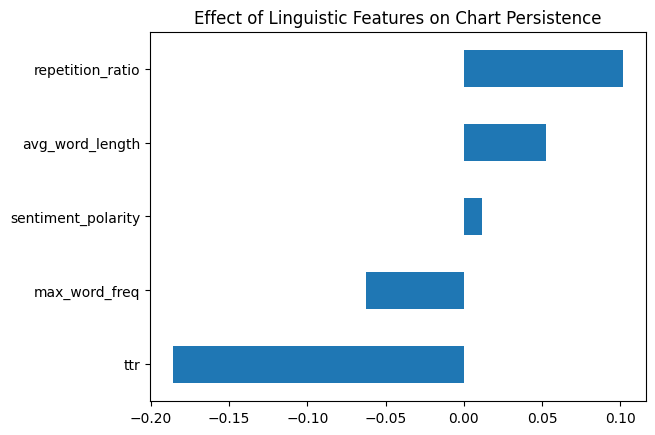

In [427]:
coef[linguistic_cols].sort_values().plot(kind="barh")
plt.title("Effect of Linguistic Features on Chart Persistence")
plt.show()

### TF-IDF Interpretation

In [ ]:
coef_words = coef[X_tfidf_train_selected.columns]

# Remove repeated bigrams (e.g., "yeah yeah")
coef_words = coef_words[~coef_words.index.str.match(r'^(\w+)\s+\1$')]

top_positive = coef_words.sort_values(ascending=False).head(20)
top_negative = coef_words.sort_values().head(20)

### Plot top words

In [ ]:
palette = ["#9B59B6"] * len(top_positive)

# ── Positive words ──────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.barh(
    top_positive.sort_values().index,
    top_positive.sort_values().values,
    color=palette
)

axes.set_title(
    "Top Words → Long Chart Persistence",
    fontweight="bold",
    fontsize=13
)
axes.set_xlabel("Coefficient")
axes.set_ylabel("")

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(OUTPUTS / "top_positive_words.png", dpi=300, bbox_inches="tight")
plt.show()


# ── Negative words ──────────────────────────────────────────
palette = ["#3AA5A0"] * len(top_negative)

fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.barh(
    top_negative.sort_values().index,
    top_negative.sort_values().values,
    color=palette
)

axes.set_title(
    "Top Words → Short Chart Persistence",
    fontweight="bold",
    fontsize=13
)
axes.set_xlabel("Coefficient")
axes.set_ylabel("")

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(OUTPUTS / "top_negative_words.png", dpi=300, bbox_inches="tight")
plt.show()